In [1]:
from pathlib import Path
import subprocess

REPO_URL = "https://github.com/seoultechpse/fenicsx-colab.git"
ROOT = Path("/content")
REPO_DIR = ROOT / "fenicsx-colab"

subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)

USE_COMPLEX = False  # <--- Set True ONLY if you need complex PETSc
USE_CLEAN = False    # <--- Set True to remove existing environment

opts_str = " ".join(
  [o for c, o in [(USE_COMPLEX, "--complex"), (USE_CLEAN, "--clean")] if c]
)

get_ipython().run_line_magic("run", f"{REPO_DIR / 'setup_fenicsx.py'} {opts_str}")

🔧 FEniCSx Setup Configuration
PETSc type      : real
Clean install   : False

⚠️  Google Drive not mounted — using local cache (/content)

🔧 Installing FEniCSx environment...

🔍 Verifying PETSc type...
✅ Installed: Real PETSc (float64)

✨ Loading FEniCSx Jupyter magic... %%fenicsx registered

✅ FEniCSx setup complete!

Next steps:
  1. Run %%fenicsx --info to verify installation
  2. Use %%fenicsx in cells to run FEniCSx code
  3. Use -np N for parallel execution (e.g., %%fenicsx -np 4)

📌 Note: Real PETSc is installed
   - Recommended for most FEM problems
   - For complex problems, reinstall with --complex


---

In [2]:
%%fenicsx

"""
PDE-Constrained Optimization Example using UFL Adjoint

This example demonstrates the Poisson optimal control problem.

Goal: Control heat source f to make temperature distribution u close to target d
"""

import basix.ufl
import ufl

# ============================================================================
# 1. Domain and Function Space Definition
# ============================================================================

print("=" * 70)
print("1. Function Space Setup")
print("=" * 70)

# Define 2D triangular mesh
domain = ufl.Mesh(basix.ufl.element("Lagrange", "triangle", 1, shape=(2,)))
print("✓ Domain created: 2D triangular mesh")

# Function space for state variable u (continuous P1 Lagrange elements)
el_u = basix.ufl.element("Lagrange", "triangle", 1)
V = ufl.FunctionSpace(domain, el_u)
print("✓ State variable space V: continuous P1 elements")

# Function space for control variable f (discontinuous P0 elements)
el_f = basix.ufl.element("DG", "triangle", 0)
Q = ufl.FunctionSpace(domain, el_f)
print("✓ Control variable space Q: discontinuous P0 elements")

print()

# ============================================================================
# 2. Functions and Coefficients Definition
# ============================================================================

print("=" * 70)
print("2. Functions and Coefficients Definition")
print("=" * 70)

# Control variable (heat source)
f = ufl.Coefficient(Q)
print("✓ Control variable f (heat source) defined")

# State variable (temperature)
u = ufl.Coefficient(V)
print("✓ State variable u (temperature) defined")

# Test function
v = ufl.TestFunction(V)
print("✓ Test function v defined")

# Target temperature distribution
d = ufl.Coefficient(V)
print("✓ Target temperature d defined")

# Regularization parameter
alpha = ufl.Constant(domain)
print("✓ Regularization parameter α defined")

print()

# ============================================================================
# 3. Forward Problem (PDE Constraint)
# ============================================================================

print("=" * 70)
print("3. Forward Problem: Poisson Equation")
print("=" * 70)
print("PDE: -∇·∇u = f  in Ω")
print("BC:  u = 0       on ∂Ω")
print()

# Weak form: ∫∇u·∇v dx - ∫f·v dx = 0
F = ufl.inner(ufl.grad(u), ufl.grad(v)) * ufl.dx - ufl.inner(f, v) * ufl.dx

print("Weak form F(u,f;v) = 0:")
print("  F = ∫∇u·∇v dx - ∫f·v dx")
print()

# ============================================================================
# 4. Objective Function Definition
# ============================================================================

print("=" * 70)
print("4. Objective Function Definition")
print("=" * 70)
print("J(u,f) = 1/2 ∫(u-d)² dx + α/2 ∫f² dx")
print()
print("  First term: tracking accuracy (matching target)")
print("  Second term: control size regularization")
print()

# Objective function
J = 1 / 2 * (u - d) ** 2 * ufl.dx + alpha / 2 * ufl.inner(f, f) * ufl.dx

print("✓ Objective function J defined")
print()

# ============================================================================
# 5. Automatic Differentiation: Jacobian and Gradient Computation
# ============================================================================

print("=" * 70)
print("5. Automatic Differentiation")
print("=" * 70)

# Derivatives of objective function
dJdu = ufl.derivative(J, u)
dJdf = ufl.derivative(J, f)
print("✓ ∂J/∂u computed (derivative of objective w.r.t. state)")
print("✓ ∂J/∂f computed (derivative of objective w.r.t. control)")

# Derivatives of PDE constraint
dFdu = ufl.derivative(F, u)
dFdf = ufl.derivative(F, f)
print("✓ ∂F/∂u computed (Jacobian of PDE w.r.t. state)")
print("✓ ∂F/∂f computed (Jacobian of PDE w.r.t. control)")

print()

# ============================================================================
# 6. Adjoint Problem Construction
# ============================================================================

print("=" * 70)
print("6. Adjoint Problem")
print("=" * 70)
print("Adjoint equation: (∂F/∂u)* λ = -(∂J/∂u)*")
print()

# Left and right hand sides of adjoint problem
adj_lhs = ufl.adjoint(dFdu)
adj_rhs = -dJdu

print("✓ Adjoint LHS: (∂F/∂u)* (transpose operator)")
print("✓ Adjoint RHS: -(∂J/∂u)*")
print()

print("Interpretation:")
print("  - Adjoint problem is the 'mirror image' of forward problem")
print("  - λ represents the 'shadow price' of state variable u")
print("  - Same computational cost as forward problem")
print()

# ============================================================================
# 7. Linearization for Newton Method
# ============================================================================

print("=" * 70)
print("7. Newton Method Preparation")
print("=" * 70)

# For forward problem
fwd_lhs = dFdu  # Jacobian for Newton method
fwd_rhs = F  # Residual for Newton method

print("✓ Forward Newton system:")
print("  - LHS: ∂F/∂u (Jacobian matrix)")
print("  - RHS: F (Residual)")
print()

# ============================================================================
# 8. Gradient with Respect to Control
# ============================================================================

print("=" * 70)
print("8. Optimization Gradient Computation")
print("=" * 70)
print("dL/df = ∂J/∂f + (λ, ∂F/∂f)")
print()

# Adjoint variable
lmbda = ufl.Coefficient(V)
print("✓ Adjoint variable λ defined")

# Derivative of Lagrangian w.r.t. control
# ufl.action() computes matrix-vector product without assembling matrix
dLdf = ufl.derivative(J, f) + ufl.action(ufl.adjoint(dFdf), lmbda)

print("✓ dL/df computed (optimization gradient)")
print()

print("Using ufl.action():")
print("  - Computes A*x without explicitly assembling matrix A")
print("  - Memory efficient")
print("  - Beneficial for large-scale problems")
print()

# ============================================================================
# 9. Collect All Forms
# ============================================================================

print("=" * 70)
print("9. Forms Collection")
print("=" * 70)

forms = [adj_lhs, adj_rhs, fwd_lhs, fwd_rhs, dLdf, J]

form_names = [
    "adj_lhs: Adjoint LHS",
    "adj_rhs: Adjoint RHS",
    "fwd_lhs: Forward Jacobian",
    "fwd_rhs: Forward Residual",
    "dLdf: Control Gradient",
    "J: Objective Function",
]

print("Collected forms:")
for i, (form, name) in enumerate(zip(forms, form_names)):
    print(f"  [{i}] {name}")

print()

# ============================================================================
# 10. Optimization Algorithm Overview
# ============================================================================

print("=" * 70)
print("10. Optimization Algorithm (Reduced Space Approach)")
print("=" * 70)
print()
print("At iteration k:")
print("  1. Forward solve:  F(u^k, f^k) = 0  →  u^k")
print("  2. Objective:      J^k = J(u^k, f^k)")
print("  3. Adjoint solve:  (∂F/∂u)* λ^k = -(∂J/∂u)*  →  λ^k")
print("  4. Gradient:       g^k = ∂J/∂f + (λ^k, ∂F/∂f)")
print("  5. Update:         f^(k+1) = f^k - β·g^k")
print("  6. Check convergence")
print()
print("Convergence criteria: ||g^k|| < tol  or  |J^k - J^(k-1)| < tol")
print()

# ============================================================================
# 11. Computational Efficiency Analysis
# ============================================================================

print("=" * 70)
print("11. Computational Efficiency")
print("=" * 70)
print()
print("Cost per iteration:")
print("  - Forward solve:  1 time")
print("  - Adjoint solve:  1 time")
print("  - Gradient:       O(1) (no matrix assembly)")
print()
print("Total cost = O(# iterations) × O(PDE solve)")
print()
print("Advantage over direct differentiation:")
print("  - Direct method: O(control dimension) × O(PDE solve)")
print("  - Adjoint method: O(1) × O(PDE solve)")
print("  - Adjoint is overwhelmingly efficient for high-dimensional controls!")
print()

# ============================================================================
# 12. Summary and Next Steps
# ============================================================================

print("=" * 70)
print("12. Summary")
print("=" * 70)
print()
print("✓ PDE-constrained optimization problem formulated using UFL")
print("✓ 6 variational forms created:")
print("  - Forward problem (LHS, RHS)")
print("  - Adjoint problem (LHS, RHS)")
print("  - Optimization gradient")
print("  - Objective function")
print()
print("Next steps (in DOLFINx):")
print("  1. Generate actual mesh")
print("  2. Apply boundary conditions")
print("  3. Assemble and solve forms")
print("  4. Implement optimization algorithm")
print("  5. Visualize results")
print()

# ============================================================================
# Appendix: Form Structure Inspection
# ============================================================================

print("=" * 70)
print("Appendix: Form Structure Inspection")
print("=" * 70)
print()

print("Forward Jacobian (fwd_lhs) integrand:")
print(f"  {dFdu.integrals()[0].integrand()}")
print()

print("Forward Jacobian structure:")
print("  - Bilinear form: a(δu, v)")
print("  - Arguments: (TrialFunction, TestFunction)")
print("  - Symmetric: Results in symmetric matrix for Poisson problem")
print()

print("=" * 70)
print("Example code complete!")
print("=" * 70)


1. Function Space Setup
✓ Domain created: 2D triangular mesh
✓ State variable space V: continuous P1 elements
✓ Control variable space Q: discontinuous P0 elements

2. Functions and Coefficients Definition
✓ Control variable f (heat source) defined
✓ State variable u (temperature) defined
✓ Test function v defined
✓ Target temperature d defined
✓ Regularization parameter α defined

3. Forward Problem: Poisson Equation
PDE: -∇·∇u = f  in Ω
BC:  u = 0       on ∂Ω

Weak form F(u,f;v) = 0:
  F = ∫∇u·∇v dx - ∫f·v dx

4. Objective Function Definition
J(u,f) = 1/2 ∫(u-d)² dx + α/2 ∫f² dx

  First term: tracking accuracy (matching target)
  Second term: control size regularization

✓ Objective function J defined

5. Automatic Differentiation
✓ ∂J/∂u computed (derivative of objective w.r.t. state)
✓ ∂J/∂f computed (derivative of objective w.r.t. control)
✓ ∂F/∂u computed (Jacobian of PDE w.r.t. state)
✓ ∂F/∂f computed (Jacobian of PDE w.r.t. control)

6. Adjoint Problem
Adjoint equation: (∂F/∂u

---

In [3]:
%%fenicsx

"""
Complete PDE-Constrained Optimization using UFL Adjoint

Final version with proper gradient computation and Colab-compatible visualization.
"""

import numpy as np
import ufl
from dolfinx import fem, mesh, plot, io
from dolfinx.fem.petsc import LinearProblem
from mpi4py import MPI
from petsc4py import PETSc

# ============================================================================
# 1. Mesh and Function Space Creation
# ============================================================================

print("=" * 70)
print("1. Mesh and Function Space Creation")
print("=" * 70)

nx, ny = 32, 32
domain = mesh.create_unit_square(MPI.COMM_WORLD, nx, ny, mesh.CellType.triangle)
print(f"✓ Mesh created: {nx}×{ny} = {nx*ny*2} triangular elements")

V = fem.functionspace(domain, ("Lagrange", 1))
print(f"✓ State variable space V: {V.dofmap.index_map.size_global} DOFs")

Q = fem.functionspace(domain, ("DG", 0))
print(f"✓ Control variable space Q: {Q.dofmap.index_map.size_global} DOFs")

print()

# ============================================================================
# 2. Target Temperature Distribution
# ============================================================================

print("=" * 70)
print("2. Target Temperature Distribution Setup")
print("=" * 70)

d = fem.Function(V)
d.interpolate(lambda x: np.sin(np.pi * x[0]) * np.sin(np.pi * x[1]))
print("✓ Target temperature: d(x,y) = sin(πx)sin(πy)")

alpha_value = 1e-5  # 1e-4  # 1e-3
alpha = fem.Constant(domain, PETSc.ScalarType(alpha_value))
print(f"✓ Regularization parameter: α = {alpha_value}")

print()

# ============================================================================
# 3. Boundary Conditions
# ============================================================================

print("=" * 70)
print("3. Boundary Condition Setup")
print("=" * 70)

tdim = domain.topology.dim
fdim = tdim - 1
domain.topology.create_connectivity(fdim, tdim)
boundary_facets = mesh.exterior_facet_indices(domain.topology)

boundary_dofs = fem.locate_dofs_topological(V, fdim, boundary_facets)
bc = fem.dirichletbc(PETSc.ScalarType(0), boundary_dofs, V)
print(f"✓ Dirichlet BC: u = 0 on ∂Ω ({len(boundary_dofs)} DOFs)")

print()

# ============================================================================
# 4. Forward Problem Setup
# ============================================================================

print("=" * 70)
print("4. Forward Problem Setup")
print("=" * 70)

f = fem.Function(Q)
f.x.array[:] = 0.0
print("✓ Initial control: f = 0")

u = fem.Function(V)
u_trial = ufl.TrialFunction(V)
v = ufl.TestFunction(V)

a_fwd = ufl.inner(ufl.grad(u_trial), ufl.grad(v)) * ufl.dx
L_fwd = ufl.inner(f, v) * ufl.dx

try:
    problem_fwd = LinearProblem(
        a_fwd, L_fwd, bcs=[bc],
        petsc_options={"ksp_type": "preonly", "pc_type": "lu"},
        petsc_options_prefix="fwd_"
    )
except TypeError:
    problem_fwd = LinearProblem(
        a_fwd, L_fwd, bcs=[bc],
        petsc_options={"ksp_type": "preonly", "pc_type": "lu"}
    )

u = problem_fwd.solve()
print("✓ Forward problem solved")

J_value = fem.assemble_scalar(
    fem.form(1/2 * (u - d)**2 * ufl.dx + alpha/2 * ufl.inner(f, f) * ufl.dx)
)
print(f"✓ Initial objective: J = {J_value:.6e}")

print()

# ============================================================================
# 5. Adjoint Problem Setup
# ============================================================================

print("=" * 70)
print("5. Adjoint Problem Setup")
print("=" * 70)

lmbda = fem.Function(V)
lmbda_trial = ufl.TrialFunction(V)

a_adj = ufl.inner(ufl.grad(lmbda_trial), ufl.grad(v)) * ufl.dx
L_adj = -ufl.inner(u - d, v) * ufl.dx

try:
    problem_adj = LinearProblem(
        a_adj, L_adj, bcs=[bc],
        petsc_options={"ksp_type": "preonly", "pc_type": "lu"},
        petsc_options_prefix="adj_"
    )
except TypeError:
    problem_adj = LinearProblem(
        a_adj, L_adj, bcs=[bc],
        petsc_options={"ksp_type": "preonly", "pc_type": "lu"}
    )

lmbda = problem_adj.solve()
print("✓ Adjoint problem solved")
print(f"  ||λ|| in V space = {np.linalg.norm(lmbda.x.array):.6f}")

print()

# ============================================================================
# 6. Gradient Computation
# ============================================================================

print("=" * 70)
print("6. Gradient Computation")
print("=" * 70)

# Project λ from V to Q
lmbda_Q = fem.Function(Q)
lmbda_Q.interpolate(lmbda)
print(f"✓ λ projected to Q: ||λ_Q|| = {np.linalg.norm(lmbda_Q.x.array):.6f}")

# Compute gradient directly: dL/df = α·f - λ_Q
gradient = fem.Function(Q)
gradient.x.array[:] = alpha_value * f.x.array[:] - lmbda_Q.x.array[:]

gradient_norm = np.linalg.norm(gradient.x.array)
print(f"✓ Gradient computed: ||∇J|| = {gradient_norm:.6f}")

print()

# ============================================================================
# 7. Optimization Loop (with XDMF output)
# ============================================================================

print("=" * 70)
print("7. Optimization Iteration")
print("=" * 70)

max_iter = 100
tolerance = 1e-4
step_size = 50.0

print(f"Optimization settings:")
print(f"  - Max iterations: {max_iter}")
print(f"  - Tolerance: {tolerance}")
print(f"  - Initial step: {step_size}")
print()

J_history = [J_value]
grad_history = [gradient_norm]

print(f"{'Iter':<6} {'J(f)':<14} {'||∇J||':<14} {'Step':<12} {'Reduction':<12}")
print("-" * 65)
print(f"{0:<6} {J_value:<14.6e} {gradient_norm:<14.6e} {'-':<12} {'-':<12}")

xdmf = io.XDMFFile(domain.comm, "optimization_timeseries.xdmf", "w")
xdmf.write_mesh(domain)

for iteration in range(1, max_iter + 1):
    f_old = f.x.array.copy()
    J_old = J_value

    # Armijo line search
    beta = 0.5
    sigma = 1e-4
    step = step_size

    for ls_iter in range(20):
        # Gradient descent step
        f.x.array[:] = f_old - step * gradient.x.array[:]

        # Solve forward
        u = problem_fwd.solve()

        # Compute objective
        J_value = fem.assemble_scalar(
            fem.form(1/2 * (u - d)**2 * ufl.dx + alpha/2 * ufl.inner(f, f) * ufl.dx)
        )

        # Armijo condition
        if J_value <= J_old - sigma * step * gradient_norm**2:
            break
        step *= beta
    else:
        print(f"  ⚠️  Line search failed at iteration {iteration}")
        break

    # Solve adjoint
    lmbda = problem_adj.solve()

    # --- Save fields for ParaView (time-series) ---
    u.name = "u"
    f.name = "f"
    lmbda.name = "lambda"

    xdmf.write_function(u, t=float(iteration))
    xdmf.write_function(f, t=float(iteration))
    xdmf.write_function(lmbda, t=float(iteration))

    # Project and compute gradient
    lmbda_Q.interpolate(lmbda)
    gradient.x.array[:] = alpha_value * f.x.array[:] - lmbda_Q.x.array[:]
    gradient_norm = np.linalg.norm(gradient.x.array)

    # Save history
    J_history.append(J_value)
    grad_history.append(gradient_norm)

    # Print progress
    reduction = (J_history[0] - J_value) / J_history[0] * 100
    print(f"{iteration:<6} {J_value:<14.6e} {gradient_norm:<14.6e} {step:<12.5e} {reduction:<12.2f}%")

    # Check convergence
    if gradient_norm < tolerance:
        print()
        print(f"✓ Converged at iteration {iteration}")
        break

    # Adapt step size
    if J_value < J_old:
        step_size = min(1.2 * step, 200.0)
    else:
        step_size *= 0.5

xdmf.close()
print("✓ ParaView time-series saved to 'optimization_timeseries.xdmf'")
print()

# ============================================================================
# 8. Results Summary
# ============================================================================

print("=" * 70)
print("8. Optimization Results")
print("=" * 70)

print(f"Initial objective: J₀ = {J_history[0]:.6e}")
print(f"Final objective:   J* = {J_history[-1]:.6e}")
print(f"Reduction:         {(1 - J_history[-1]/J_history[0])*100:.2f}%")
print()
print(f"Initial gradient: ||∇J₀|| = {grad_history[0]:.6e}")
print(f"Final gradient:   ||∇J*|| = {grad_history[-1]:.6e}")
print(f"Reduction:        {(1 - grad_history[-1]/grad_history[0])*100:.2f}%")
print()

print("Optimal control f*:")
print(f"  - min:  {f.x.array.min():.6e}")
print(f"  - max:  {f.x.array.max():.6e}")
print(f"  - mean: {f.x.array.mean():.6e}")
print(f"  - ||f*||: {np.linalg.norm(f.x.array):.6e}")
print()

error = fem.assemble_scalar(fem.form((u - d)**2 * ufl.dx))**0.5
initial_error = fem.assemble_scalar(fem.form(d**2 * ufl.dx))**0.5
print(f"State error:")
print(f"  - Initial: ||u₀ - d|| = {initial_error:.6e}")
print(f"  - Final:   ||u* - d|| = {error:.6e}")
print(f"  - Reduction: {(1 - error/initial_error)*100:.2f}%")
print()

# ============================================================================
# 9. Save Convergence History
# ============================================================================

print("=" * 70)
print("9. Save Results")
print("=" * 70)

history_data = np.column_stack([
    range(len(J_history)),
    J_history,
    grad_history[:len(J_history)]
])
np.savetxt("optimization_history.csv", history_data,
           delimiter=",", header="Iteration,Objective,Gradient_Norm", comments="")
print("✓ History saved to 'optimization_history.csv'")

# ============================================================================
# 10. Plot Convergence
# ============================================================================

print()
print("=" * 70)
print("10. Plot Convergence History")
print("=" * 70)

try:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot objective function
    ax1 = axes[0]
    ax1.semilogy(J_history, 'b-o', linewidth=2, markersize=5)
    ax1.set_xlabel('Iteration', fontsize=12)
    ax1.set_ylabel('Objective J(f)', fontsize=12)
    ax1.set_title('Objective Function Convergence', fontsize=14, weight='bold')
    ax1.grid(True, alpha=0.3)

    # Plot gradient norm
    ax2 = axes[1]
    ax2.semilogy(grad_history, 'r-s', linewidth=2, markersize=5)
    ax2.set_xlabel('Iteration', fontsize=12)
    ax2.set_ylabel('||∇J||', fontsize=12)
    ax2.set_title('Gradient Norm Convergence', fontsize=14, weight='bold')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('convergence_history.png', dpi=150, bbox_inches='tight')
    print("✓ Plot saved to 'convergence_history.png'")

except ImportError:
    print("Matplotlib not available")
except Exception as e:
    print(f"Plotting error: {e}")

print()

# ============================================================================
# 11. Alternative Matplotlib Visualization for Colab
# ============================================================================

print("=" * 70)
print("11. Alternative Matplotlib Visualization")
print("=" * 70)

try:
    import matplotlib.pyplot as plt
    from matplotlib.tri import Triangulation

    # ------------------------------------------------------------------
    # Mesh data
    # ------------------------------------------------------------------
    coords = domain.geometry.x

    tdim = domain.topology.dim
    domain.topology.create_connectivity(tdim, 0)
    cells = domain.topology.connectivity(tdim, 0).array.reshape(-1, 3)

    triang = Triangulation(coords[:, 0], coords[:, 1], cells)

    fig, axes = plt.subplots(2, 2, figsize=(14, 12))

    # Target d (P1)
    ax = axes[0, 0]
    tpc = ax.tripcolor(
        triang, d.x.array,
        shading="gouraud", cmap="viridis"
    )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_title("Target temperature d(x,y)", fontsize=14, weight="bold")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    plt.colorbar(tpc, ax=ax)

    # Optimal state u* (P1)
    ax = axes[0, 1]
    tpc = ax.tripcolor(
        triang, u.x.array,
        shading="gouraud", cmap="viridis",
        vmin=0.0, vmax=1.0
    )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_title("Optimal state u*(x,y)", fontsize=14, weight="bold")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    plt.colorbar(tpc, ax=ax)

    # Optimal control f* (DG0 → flat shading)
    ax = axes[1, 0]
    tpc = ax.tripcolor(
        triang, f.x.array,
        shading="flat", cmap="coolwarm"
    )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_title("Optimal control f*(x,y) [DG0]", fontsize=14, weight="bold")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    plt.colorbar(tpc, ax=ax)

    # |u - d| error field (P1)
    error_ud = np.abs(u.x.array - d.x.array)

    ax = axes[1, 1]

    tpc_err = ax.tripcolor(
        triang,
        error_ud,
        shading="gouraud",
        cmap="magma",
        vmin=0.0,
        vmax=error_ud.max() # 또는 고정값 (예: 0.3)
    )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_title(r"Error field $|u^* - d|$", fontsize=14, weight="bold")

    cbar = plt.colorbar(tpc_err, ax=ax)
    cbar.set_label(r"$|u-d|$", rotation=270, labelpad=15)

    # # Adjoint λ (P1)
    # ax = axes[1, 1]
    # tpc = ax.tripcolor(
    #     triang, lmbda.x.array,
    #     shading="gouraud", cmap="plasma"
    # )

    # ax.set_xlim(0, 1)
    # ax.set_ylim(0, 1)
    # ax.set_aspect("equal")

    # for spine in ax.spines.values():
    #     spine.set_visible(False)

    # ax.set_title("Adjoint variable λ(x,y)", fontsize=14, weight="bold")
    # ax.set_xlabel("x")
    # ax.set_ylabel("y")
    # plt.colorbar(tpc, ax=ax)

    # -------------------------------------------------------------

    plt.tight_layout()
    plt.savefig(
        "solution_fields_matplotlib.png",
        dpi=150, bbox_inches="tight"
    )
    print("✓ Matplotlib visualization saved to 'solution_fields_matplotlib.png'")

except Exception as e:
    print(f"Matplotlib visualization error: {e}")

print()
print("=" * 70)
print("OPTIMIZATION COMPLETE!")
print("=" * 70)
print()
print("Output files:")
print("  - optimization_history.csv")
print("  - optimization_timeseries.xdmf")
print("  - convergence_history.png")
print("  - solution_fields_matplotlib.png")



1. Mesh and Function Space Creation
✓ Mesh created: 32×32 = 2048 triangular elements
✓ State variable space V: 1089 DOFs
✓ Control variable space Q: 2048 DOFs

2. Target Temperature Distribution Setup
✓ Target temperature: d(x,y) = sin(πx)sin(πy)
✓ Regularization parameter: α = 1e-05

3. Boundary Condition Setup
✓ Dirichlet BC: u = 0 on ∂Ω (128 DOFs)

4. Forward Problem Setup
✓ Initial control: f = 0
✓ Forward problem solved
✓ Initial objective: J = 1.245992e-01

5. Adjoint Problem Setup
✓ Adjoint problem solved
  ||λ|| in V space = 0.808620

6. Gradient Computation
✓ λ projected to Q: ||λ_Q|| = 1.141115
✓ Gradient computed: ||∇J|| = 1.141115

7. Optimization Iteration
Optimization settings:
  - Max iterations: 100
  - Tolerance: 0.0001
  - Initial step: 50.0

Iter   J(f)           ||∇J||         Step         Reduction   
-----------------------------------------------------------------
0      1.245992e-01   1.141115e+00   -            -           
1      9.484435e-02   9.949705e-01   

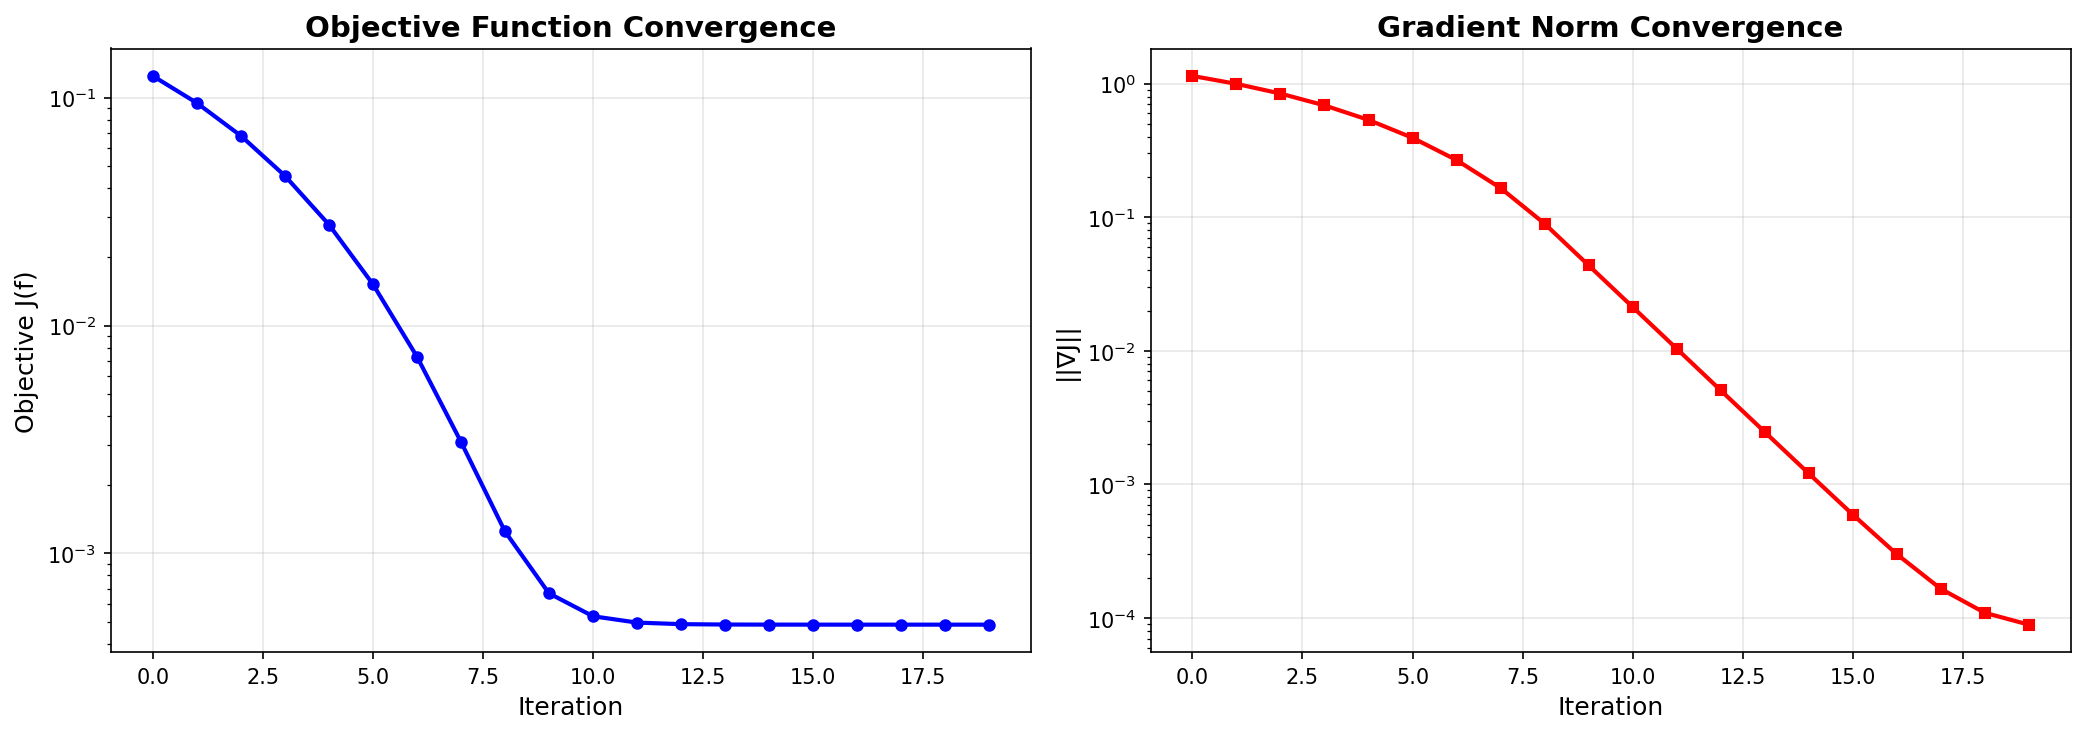

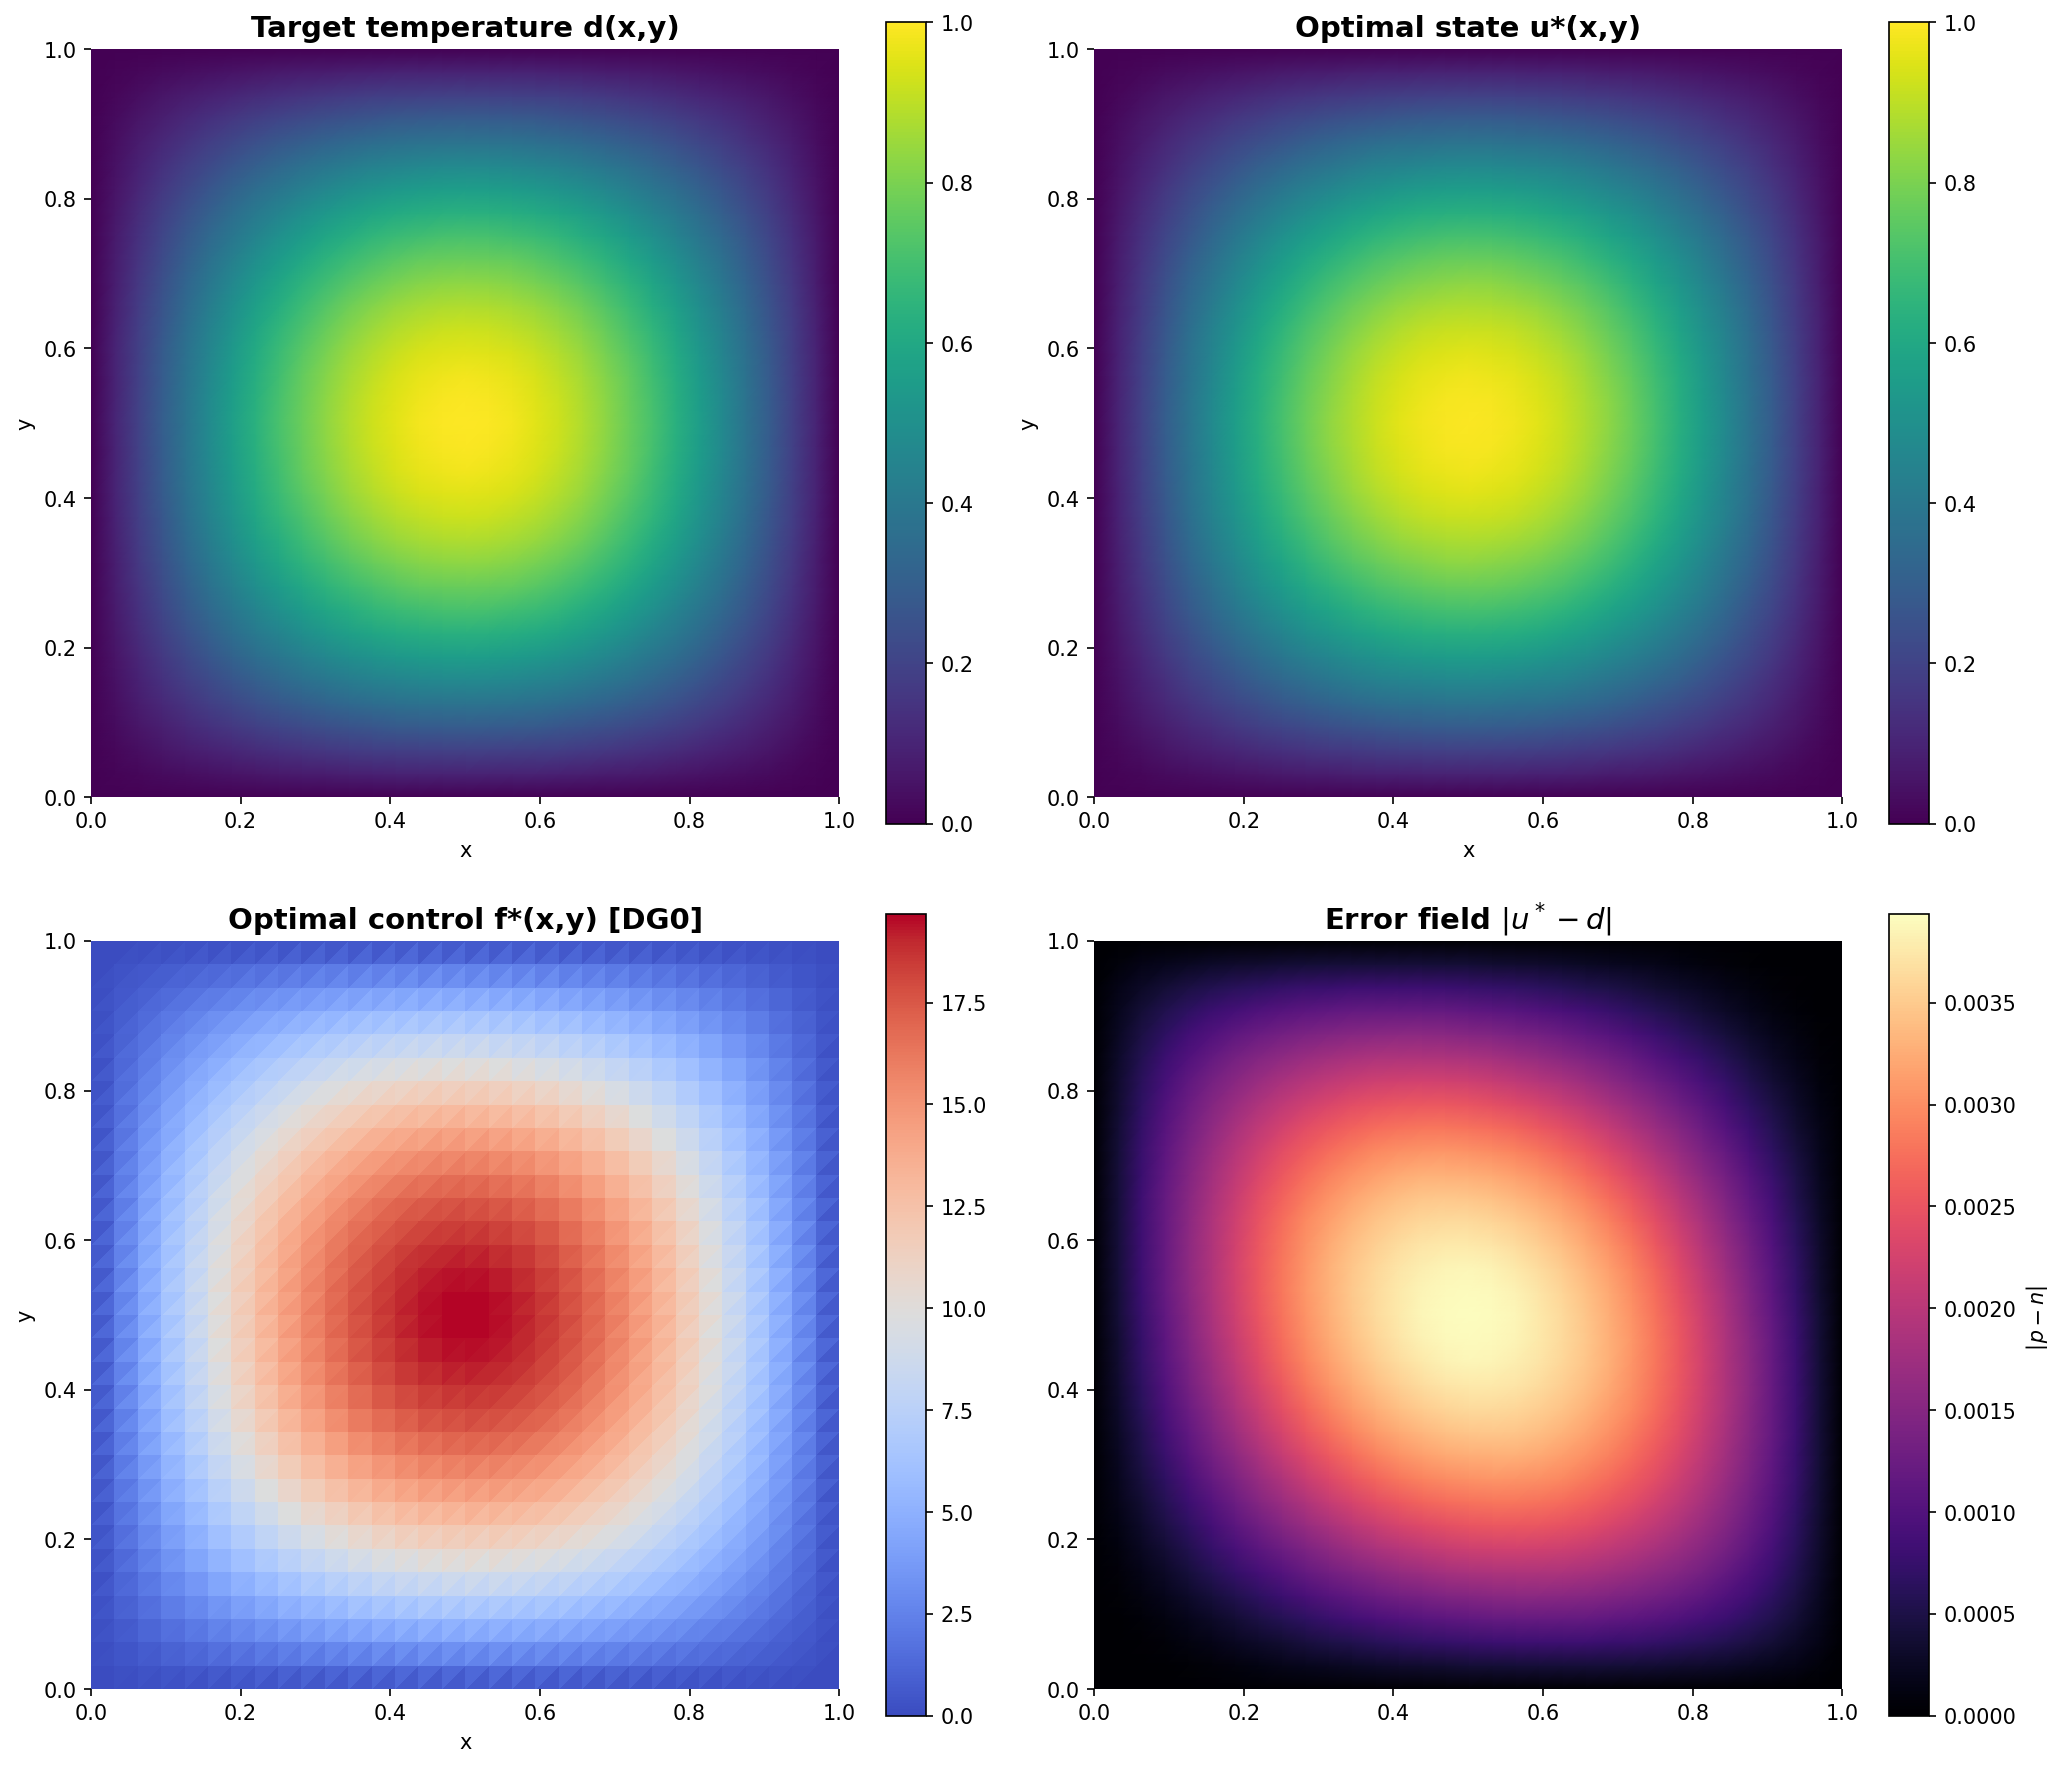

In [4]:
from IPython.display import Image, display

display(Image("convergence_history.png"))
display(Image("solution_fields_matplotlib.png"))

In [5]:
from google.colab import files

files.download('optimization_timeseries.xdmf')
files.download('optimization_timeseries.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>